# Import libs

In [5]:
import numpy as np
from typing import Tuple, Optional
import sys

import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

import numpy as np
from typing import Tuple, Dict

sys.path.append("../..")
from src.data.SythData import SythDataConstructor

# Define Syth Class

In [2]:
class RandomChangePointsGenerator:
    """Improved version that distributes change points more uniformly"""

    def __init__(self,
                 seed: Optional[int] = None,
                 cps_number: int = 0,
                 length_data: int = 24 * 7 * 15 + 15,
                 minimum_sequence_cp: int = 10,
                 start_mutation_coeff: float = 0.5,
                 treshold_mutation_coeff: float = 0.1,
                 power_coeff: float = 1.2,
                 attemps_to_failure: int = 15):

        if seed is None:
            seed = np.random.randint(low=0, high=65535)
        np.random.seed(seed)

        self.seed = seed
        self.cps_number = cps_number
        self.length_data = length_data
        self.power_coeff = power_coeff
        self.start_mutation_coeff = start_mutation_coeff
        self.treshold_mutation_coeff = treshold_mutation_coeff
        self.minimum_sequence_cp = minimum_sequence_cp
        self.attemps_to_failure = attemps_to_failure

        if cps_number < 0:
            raise AttributeError(f"Change points number has to be positive! However, you set it to be {cps_number}")

        if length_data < 10:
            raise NotImplementedError("This class expects to generate array with more than 10 values in a sequence!")

        if (length_data / (cps_number + 1e-9)) < minimum_sequence_cp:
            raise NotImplementedError("Expected length of data is too small for expected cps_number! One of your "
                                      "sequences could be less than minimum_sequence_cp points which may lead to errors.")

    def _new_mutation_coeff(self, sequence_len: int) -> float:
        """Generate random float value between 0 and 1."""
        if sequence_len ** self.power_coeff > self.length_data:
            out = np.random.random() - self.treshold_mutation_coeff
        else:
            out = np.random.random()
        return out

    def _is_mutation_apply(self, sequence_len: int, past_mutation_coeff: float) -> bool:
        """Determine if we should apply mutation factor"""
        if sequence_len > self.minimum_sequence_cp:
            # Adjust probability based on position in sequence to encourage uniform distribution
            position_factor = sequence_len / self.length_data
            adjusted_prob = past_mutation_coeff * (1 + position_factor)
            return np.random.random() > adjusted_prob
        return False

    def queue(self, queue_window: int, time_series: np.array) -> np.array:
        """Ensure minimum distance between change points"""
        cp_indices = np.where(time_series == 1)[0]
        for i in range(1, len(cp_indices)):
            if cp_indices[i] - cp_indices[i - 1] < queue_window:
                # Remove the latter change point if too close
                time_series[cp_indices[i]] = 0
        return time_series

    def generate_uniform_change_points(self) -> np.array:
        """Generate change points with more uniform distribution"""
        cps_array = np.zeros(self.length_data)

        if self.cps_number == 0:
            return cps_array

        # Calculate ideal spacing between change points
        ideal_spacing = self.length_data / (self.cps_number + 1)

        # Generate initial positions with some randomness
        positions = [int(i + 1 + np.random.uniform(-0.3, 0.3)) * ideal_spacing for i in range(self.cps_number)]
        positions = np.clip(positions, self.minimum_sequence_cp, self.length_data - self.minimum_sequence_cp)

        # Convert to integers and ensure uniqueness
        positions = np.unique(np.round(positions).astype(int))

        # If we didn't get enough points, add more randomly
        while len(positions) < self.cps_number:
            new_pos = np.random.randint(self.minimum_sequence_cp,
                                        self.length_data - self.minimum_sequence_cp)
            if np.min(np.abs(positions - new_pos)) > self.minimum_sequence_cp:
                positions = np.append(positions, new_pos)

        # Ensure minimum distance
        positions.sort()
        for i in range(1, len(positions)):
            if positions[i] - positions[i - 1] < self.minimum_sequence_cp:
                positions[i] = positions[i - 1] + self.minimum_sequence_cp

        cps_array[positions] = 1
        return cps_array

    def generate_change_points_with_mutation(self) -> np.array:
        """Main function to generate array of change points with uniform distribution"""
        # First try uniform generation
        cps_array = self.generate_uniform_change_points()

        # If we didn't get enough points, fall back to random
        if sum(cps_array) < self.cps_number:
            attempts = 0
            while sum(cps_array) < self.cps_number and attempts < self.attemps_to_failure:
                pos = np.random.randint(self.minimum_sequence_cp,
                                        self.length_data - self.minimum_sequence_cp)
                # Check distance from existing points
                existing = np.where(cps_array == 1)[0]
                if len(existing) == 0 or np.min(np.abs(existing - pos)) > self.minimum_sequence_cp:
                    cps_array[pos] = 1
                attempts += 1

        # Final check and queue filtering
        cps_array = self.queue(self.minimum_sequence_cp, cps_array)

        if sum(cps_array) < self.cps_number:
            print(f"Warning: Only generated {sum(cps_array)} change points out of requested {self.cps_number}")

        return cps_array

    def generate_change_points_with_random(self, cps_array: Optional[np.array] = None) -> np.array:
        """Alternative method using random generation with uniform distribution"""
        if cps_array is None:
            cps_array = np.zeros(self.length_data)

        positions = []
        attempts = 0

        while len(positions) < self.cps_number and attempts < self.attemps_to_failure:
            # Try to place points in different segments
            segment_size = self.length_data / (self.cps_number + 1)
            new_pos = int(np.random.uniform(len(positions) * segment_size,
                                            (len(positions) + 1) * segment_size))

            new_pos = np.clip(new_pos, self.minimum_sequence_cp, self.length_data - self.minimum_sequence_cp)

            # Check minimum distance
            if len(positions) == 0 or np.min(np.abs(np.array(positions) - new_pos)) > self.minimum_sequence_cp:
                positions.append(new_pos)
            attempts += 1

        cps_array[np.array(positions)] = 1
        return self.queue(self.minimum_sequence_cp, cps_array)

In [18]:
class LinearSteps(RandomChangePointsGenerator):
    def __init__(self, 
                 length_data: int = 1000,
                 cps_number: int = 10,
                 noise_std: float = 0.1,
                 min_segment_length: int = 20,
                 **kwargs):
        super().__init__(**kwargs)
        self.length_data = length_data
        self.cps_number = cps_number
        self.noise_std = noise_std
        self.min_segment_length = min_segment_length
    
    def get_linear_segment(self,
                         beta: float,
                         k: float,
                         segment_length: int,
                         x_start: int = 0) -> np.array:
        """Generate a linear segment with noise
        
        Args:
            beta: Intercept value
            k: Slope value
            segment_length: Length of the segment to generate
            x_start: Starting x-value for continuity
            
        Returns:
            Generated linear segment with noise
        """
        x = np.arange(x_start, x_start + segment_length)
        return k * x + beta
    
    def generate_data(self, 
                     cps: np.array,
                     initial_beta: float = -0.01,
                     initial_k: float = 0.2,
                     beta_mutation_coeff: float = 0.8,
                     k_mutation_coeff: float = 0.2) -> np.array:
        """Generate complete linear time series with change points
        
        Args:
            cps: Array of change points (1=change, 0=no change)
            initial_beta: Starting intercept
            initial_k: Starting slope
            beta_mutation_coeff: Controls intercept mutation probability (0-1)
            k_mutation_coeff: Controls slope mutation probability (0-1)
            
        Returns:
            Generated time series array
        """
        full_series = []
        current_beta = initial_beta
        current_k = initial_k
        x_position = 0
        
        # Find all change point indices
        cp_indices = np.where(cps == 1)[0]
        if len(cp_indices) == 0:
            # No change points, return single segment
            return self.get_linear_segment(current_beta, current_k, self.length_data)
        
        # Add start to change points if not present
        if cp_indices[0] != 0:
            cp_indices = np.insert(cp_indices, 0, 0)
        
        # Generate segments between change points
        for i in range(len(cp_indices)):
            start_idx = cp_indices[i]
            end_idx = cp_indices[i+1] if i+1 < len(cp_indices) else self.length_data
            segment_length = end_idx - start_idx
            
            # Only mutate parameters at change points (not at start)
            if i > 0:  # Skip first segment (uses initial values)
                # Random walk with possible mutation
                current_beta += np.random.normal(0, 0.1 * beta_mutation_coeff)
                current_k += np.random.normal(0, 0.1 * k_mutation_coeff)
                
                # Apply mutations with probability
                if np.random.random() > beta_mutation_coeff:
                    current_beta = np.random.uniform(-1, 1)
                if np.random.random() > k_mutation_coeff:
                    current_k = np.random.uniform(-1, 1)
            
            # Generate segment
            segment = self.get_linear_segment(
                beta=current_beta,
                k=current_k,
                segment_length=segment_length,
                x_start=x_position
            )
            full_series.extend(segment)
            x_position += segment_length
            
        return np.array(full_series)
    
    def get(self) -> np.ndarray:
        """Generate complete dataset with features and change points

        Returns:
            arrays of change points, noised linear signal, clean linear signal.
        """
        cps = self.generate_change_points_with_mutation()
        clean_signal = self.generate_data(cps)
        noise = np.random.normal(0, self.noise_std, self.length_data)
        return np.array([cps, clean_signal + noise, clean_signal])
    
    def plot(self, data = np.ndarray, title: str = "Linear Steps with Change Points"):
        """Visualize the generated time series"""
        if data is None:
            data = self.get()
            
        plt.figure(figsize=(12, 6))
        plt.plot(data[1], label='Noisy Signal', alpha=0.7)
        plt.plot(data[2], label='True Signal', linewidth=2)
        
        cp_indices = np.where(data[0] == 1)[0]
        for cp in cp_indices:
            plt.axvline(x=cp, color='r', linestyle='--', alpha=0.5)
            
        plt.title(title)
        plt.xlabel('Time')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True)
        plt.show()

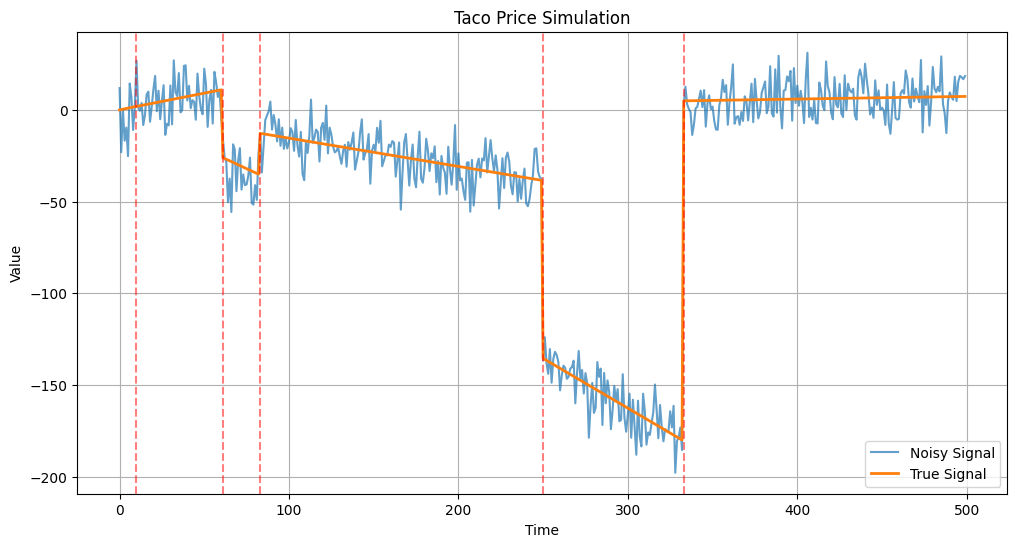

In [20]:
# Initialize generator
linear_gen = LinearSteps(
    length_data=500,
    cps_number=5,
    noise_std=10,
    min_segment_length=10
)

# Generate data
data = linear_gen.get()

# # Access components
# clean_signal = data['x']  # Clean linear steps
# noisy_signal = data['y']  # With noise added
# change_points = data['cps']  # Change point locations

# Visualize
linear_gen.plot(data, "Taco Price Simulation")